# Fase 4: Optimización de Hiperparámetros con Optuna

Este notebook visualiza y analiza gráficamente los resultados de la búsqueda de hiperparámetros ejecutada previamente en el script `src/hyperparameter_tuning.py`. 

### ¿Qué es la Optimización de Hiperparámetros?
Mientras que los parámetros convencionales de un modelo se aprenden automáticamente durante el entrenamiento con los datos, los **hiperparámetros** son las configuraciones maestras que nosotros debemos definir previamente (por ejemplo: la cantidad de árboles en un Random Forest, o la tasa de aprendizaje en un algoritmo de Boosting).

Para este proyecto utilizamos **Optuna**, un framework avanzado de optimización matemática que emplea un enfoque bayesiano (algoritmo TPE - Tree-structured Parzen Estimator). En lugar de probar combinaciones al azar, Optuna aprende inteligentemente de sus errores y aciertos pasados para encontrar la configuración óptima en el menor tiempo posible, buscando maximizar siempre nuestra métrica principal (el F1-Macro Score).

In [1]:
# Importamos las librerías necesarias para leer y visualizar el estudio de Optuna
import os
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate

# 1. Encontrar la raíz del proyecto de forma dinámica
# os.path.abspath('') nos da el directorio actual del notebook ('notebooks/')
# os.path.dirname() sube un nivel jerárquico hasta la raíz del proyecto
NOTEBOOK_DIR = os.path.abspath('')
BASE_DIR = os.path.dirname(NOTEBOOK_DIR)

# 2. Definir la ruta exacta de la base de datos según tu arquitectura (models/trained_models/)
db_path = os.path.join(BASE_DIR, "models", "trained_models", "optuna_study.db")
study_name = 'google_ads_optimization'

print(f"Buscando base de datos en: {db_path}")

# 3. Control de flujo preventivo para evitar que SQLite cree un archivo vacío
if not os.path.exists(db_path):
    raise FileNotFoundError(
        f"¡Error! No se encontró el archivo '{db_path}'. "
        "Asegúrate de ejecutar primero el script 'src/hyperparameter_tuning.py' "
        "para inicializar y completar la base de datos de Optuna."
    )

# 4. Cargamos el estudio de forma segura desde el almacenamiento persistente
study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{db_path}')

# Imprimimos el mejor resultado obtenido mediante Validación Cruzada (CV)
print("=" * 50)
print("🏆 RESULTADO GANADOR DEL ESTUDIO 🏆")
print("=" * 50)
print(f"Mejor F1-Macro Score (CV): {study.best_value:.4f}\n")

# Imprimimos la receta de configuración exacta que logró ese puntaje
print("Mejores hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"  -> {key}: {value}")

Buscando base de datos en: C:\Users\Carlos\Desktop\Dataset Ciencia de datos\google_ads_analytics\models\trained_models\optuna_study.db


🏆 RESULTADO GANADOR DEL ESTUDIO 🏆
Mejor F1-Macro Score (CV): 0.9694

Mejores hiperparámetros encontrados:
  -> use_pca: False
  -> classifier: LightGBM
  -> lgb_n_estimators: 200
  -> lgb_learning_rate: 0.2840428961162601


### 1. Historial de Optimización

El siguiente gráfico interactivo muestra cómo Optuna fue "aprendiendo" a maximizar nuestro F1-Score a lo largo de 30 intentos (*trials*).

**Análisis de los resultados:**
* Al principio (puntos azules dispersos en los primeros intentos), el rendimiento fluctuaba violentamente, llegando a caer a 0.41 con algunas configuraciones subóptimas.
* Sin embargo, gracias al algoritmo bayesiano, Optuna rápidamente aprendió de esos errores. A partir del intento 10, la línea roja (el récord histórico) se estabiliza por encima de 0.96.
* Finalmente, Optuna encontró su techo de rendimiento (0.9694) demostrando que logró converger rápidamente hacia la mejor configuración posible sin necesidad de cientos de iteraciones.

In [2]:
# Generamos el gráfico interactivo del historial de aprendizaje
plot_optimization_history(study)

### 2. Importancia de los Hiperparámetros

Este gráfico analiza estadísticamente (mediante fANOVA) qué parámetros impactaron de forma más drástica en el rendimiento final del modelo.

**Análisis de los resultados:**
* El gráfico revela de manera contundente que el hiperparámetro `classifier` tiene una importancia abrumadora (**~98%**). Esto significa que la decisión estructural de elegir algoritmos avanzados (como LightGBM) en lugar de modelos tradicionales (como SVM) dictó el éxito total del pipeline.
* Por otro lado, la decisión de comprimir los datos (`use_pca`) apenas tiene un **2%** de importancia. Esto nos confirma que la compresión espacial en este dataset específico no aportó una ventaja predictiva real, y por eso el mejor modelo prefirió no usarlo.

In [3]:
# Generamos el gráfico de importancia relativa de cada hiperparámetro
plot_param_importances(study)

### 3. Coordenadas Paralelas (Relación entre variables)

Este gráfico (ahora en versión estática para mayor claridad visual) revela las **combinaciones exactas** de hiperparámetros y cómo se relacionan con el éxito del modelo.

**Análisis de los resultados:**
* **El camino del éxito**: Si seguimos visualmente las líneas que alcanzan los puntos más altos en el eje final (Objective Value / F1-Score, cercanos a 0.97), vemos que casi todas convergen hacia el algoritmo **LightGBM**.
* **La receta ganadora**: La trayectoria que corona el gráfico nos muestra la configuración campeona: Evitar el uso de PCA (`use_pca = False`), y dentro del modelo LightGBM, utilizar un número alto de árboles (`lgb_n_estimators` en 200) combinado con una tasa de aprendizaje agresiva (`lgb_learning_rate` cercana a 0.28).
* **Los fracasos**: Las trayectorias que caen a la parte inferior del eje objetivo (los peores modelos) coinciden fuertemente con algoritmos distintos o con tasas de aprendizaje excesivamente bajas que no lograron ajustarse bien a los datos de publicidad.

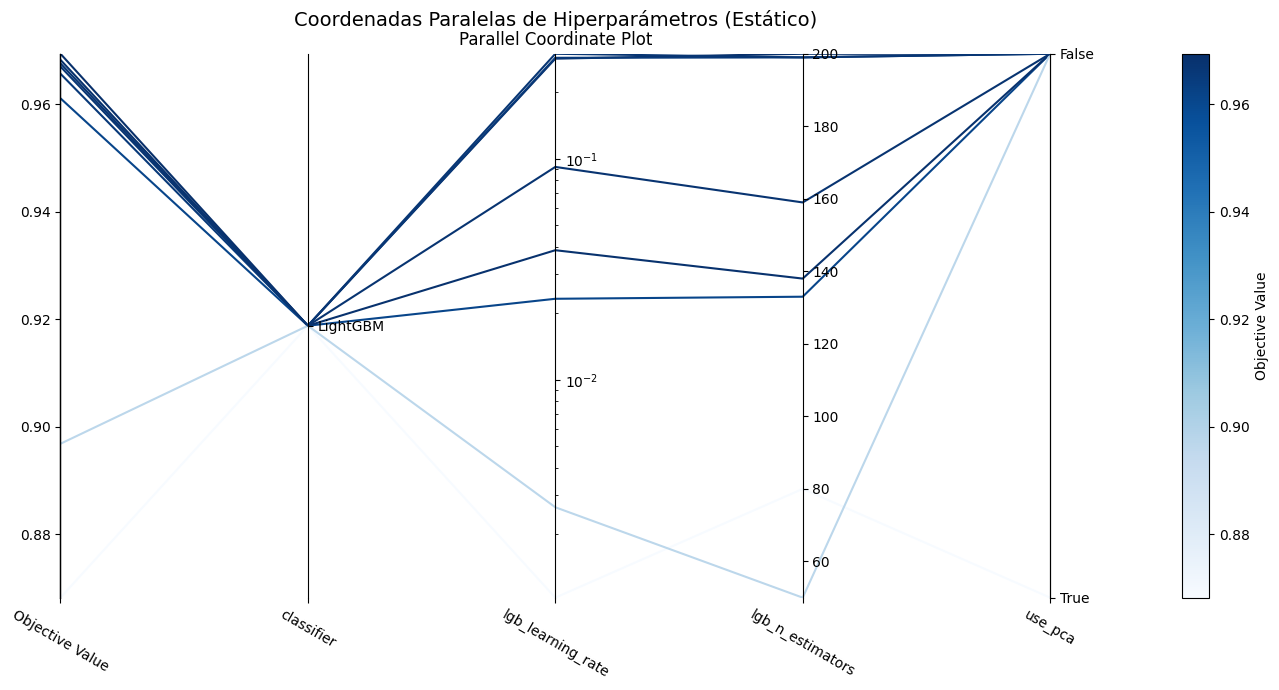

In [4]:
# Como probamos distintos algoritmos (SVM, Random Forest, etc.), no todos los intentos 
# tienen las mismas "perillas". Optuna deja el gráfico vacío porque no puede dibujar una 
# línea continua para un parámetro que no existe en todos los intentos.

# Para arreglarlo, le diremos que grafique específicamente la relación del clasificador ganador:
ganador = study.best_params['classifier']

parametros_a_graficar = ['classifier', 'use_pca']

if ganador == 'LogisticRegression':
    parametros_a_graficar.append('lr_C')
elif ganador == 'RandomForest':
    parametros_a_graficar.extend(['rf_n_estimators', 'rf_max_depth'])
elif ganador == 'SVM':
    parametros_a_graficar.extend(['svm_C', 'svm_kernel'])
elif ganador == 'XGBoost':
    parametros_a_graficar.extend(['xgb_n_estimators', 'xgb_learning_rate'])
elif ganador == 'LightGBM':
    parametros_a_graficar.extend(['lgb_n_estimators', 'lgb_learning_rate'])

# Generamos el gráfico de coordenadas paralelas solo con las variables que coinciden
from optuna.visualization.matplotlib import plot_parallel_coordinate as plot_parallel_matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 7)
ax = plot_parallel_matplotlib(study, params=parametros_a_graficar)
plt.title('Coordenadas Paralelas de Hiperparámetros (Estático)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()
